<div style="background-color:white; text-align:center; font-family:Arial, Helvetica, sans-serif; padding:50px;">
  <!-- Tytuł -->
  <div style="color:#993520; font-size:60px; font-weight:bold; margin-bottom:10px;">
    TOPIC MODELLING
  </div>

  <div style="color:#993520; font-size:30px; font-weight:bold; margin-bottom:20px;">
    Home Taken Project
  </div>

  <!-- Podtytuł -->
  <div style="color:#993520; font-size:35px; font-weight:bold; margin-bottom:40px;">
    Bigfoot Sightings Project
  </div>

  <!-- Autor -->
  <div style="color:black; font-size:30px; margin-bottom:10px;">
    Wojciech Hrycenko
  </div>

  <!-- Data / semestr -->
  <div style="color:black; font-size:30px; margin-bottom:20px;">
    Autumn 2025
  </div>

## 1. Installation of Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import re
import math
import time
import statistics
import torch
import nltk

from itertools import combinations
from collections import Counter

from nltk.tokenize import RegexpTokenizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers.modeling_utils import PreTrainedModel
from umap import umap_ as UMAP
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired

## 2. Data Loading and Preparation
We prepare the raw BFRO reports for topic modeling by aggregating relevant context and cleaning the text data:

1. **Feature Aggregation:**
   * **Combine Columns:** We merge distinct text fields (`OBSERVED`, `ENVIRONMENT`, `LOCATION_DETAILS`, etc.) into a single document string.
   * **Rationale:** Splitting the narrative across columns creates fragmented documents. Merging them ensures the model captures the full semantic context (e.g., linking the sighting description with the environmental conditions).

2. **Text Normalization:**
   * **Lowercase & Strip:** We convert all text to lowercase and remove leading/trailing whitespace to standardize the vocabulary.
   * **Fill Missing Data:** Empty cells are treated as empty strings during the merge to avoid data loss.

3. **Data Cleaning:**
   * **Drop Duplicates & Empty Rows:** We remove exact duplicates and rows that result in empty text to prevent model bias and noise.

In [ ]:

print("Loading data...")

df = pd.read_csv('bfro_reports.csv')

# BERTopic requires a list of documents (texts).

# We remove rows where text is empty (NaN) and remove duplicate tweets to avoid redundancy.



# 1. Define the columns you want to combine

cols_to_combine = [

    'OBSERVED', 'ALSO_NOTICED', 'OTHER_WITNESSES', 'OTHER_STORIES',

    'TIME_AND_CONDITIONS', 'ENVIRONMENT', 'LOCATION_DETAILS'

]



# 2. Select columns, fill empty cells (NaN) with empty text, and ensure everything is string

#    Then join the text from each row using a space as a separator

combined_series = df[cols_to_combine].fillna('').astype(str).apply(' '.join, axis=1)



# 3. Clean the resulting texts (remove excess whitespace and convert to lowercase)

combined_series = combined_series.str.strip().str.lower() # <--- CHANGE HERE



# 4. Replace empty texts (resulting from rows where all columns were empty) back to NaN,

#    so that .dropna() can be used

combined_series = combined_series.replace('', np.nan)



# 5. Apply original logic: remove empty rows (NaN) and duplicates, then create a list

docs = combined_series.dropna().drop_duplicates().tolist()

print(f"Loaded {len(docs)} unique documents.") # Changed "tweets" to "documents" for clarity



# exit() # Removed exit() so the line below can execute

print(docs[0:5]) # Print the first 5 to see the result

Loading data...
Loaded 4982 unique documents.
Sample document:
i was canoeing on the sipsey river in alabama. it was dusk as i was pulling out of the river and i was trying to hurry to get all my gear in the car before it got dark as it was about a 60 yard walk u...


Min. = 1
Max. = 30374
Mean = 1910.43
Median = 1414.5
Std. dev. = 1876.56


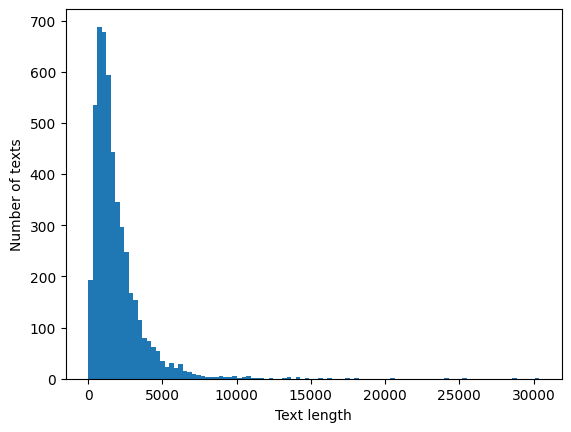

Contains duplicates? False


In [33]:

texts_lengths = [len(text) for text in docs]  # get the length of each text



# basic descriptive statistics of the texts length

print("Min. =", np.round(min(texts_lengths),2))                     # minimum length

print("Max. =", np.round(max(texts_lengths),2))                     # maximum length

print("Mean =", np.round(statistics.mean(texts_lengths),2))         # average length

print("Median =", np.round(statistics.median(texts_lengths),2))     # median length

print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))   # standard deviation



# most importantly: there are no empty documents; the shortest are 3/4 of the A4 page



# plot a histogram of text lengths

plt.hist(texts_lengths, bins=100)

plt.xlabel('Text length')

plt.ylabel('Number of texts')

plt.show()





# we should always check for duplicates; here there is no such an issue

has_duplicates = len(docs) != len(set(docs))

print("Contains duplicates?", has_duplicates)

In [34]:
# --- Stopwords Configuration ---



# Download stopwords list (only needed the first time)

try:

    nltk.data.find('corpora/stopwords')

except LookupError:

    print("Downloading NLTK stopwords...")

    nltk.download('stopwords')



# Load stopwords list

stop_words = set(nltk.corpus.stopwords.words('english'))



print(f"Stopwords list updated. Total count: {len(stop_words)}")





# --- Text Cleaning Function ---

def clean_text(text, stop_words_set):

    """

    Cleans a text string by removing URLs, mentions, 'rt' tokens,

    punctuation, numbers, single letters, stopwords, and excess whitespace,

    while keeping hashtag content.

    """

    text = str(text).lower()  # Convert to lowercase and ensure string format

   

    # Remove URLs (http or https)

    text = re.sub(r'https?://\S+', '', text)

   

    # Remove user mentions (@username)

    text = re.sub(r'@\w+', '', text)

   

    # Convert hashtags to plain text (e.g., #datascience -> datascience)

    text = re.sub(r'#(\w+)', r'\1', text)

   

    # Remove the "rt" (retweet) token

    text = re.sub(r'\brt\b', '', text)

   

    # Remove numbers

    text = re.sub(r'\d+', '', text)

   

    # Remove punctuation (keep only letters and spaces)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

   

    # Remove standalone single letters

    text = re.sub(r'\b[a-zA-Z]\b', '', text)

   

    # Remove extra whitespace

    text = re.sub(r'\s+', ' ', text).strip()



    # Remove Stopwords

    words = text.split()

    cleaned_words = [word for word in words if word not in stop_words_set]

    return ' '.join(cleaned_words)



# --- Main Code ---



print("Loading data...")

try:

    df = pd.read_csv('bfro_reports.csv')

    # Using the 'OBSERVED' column as the source text

    docs = df['OBSERVED'].dropna().drop_duplicates().tolist()

    print(f"Loaded {len(docs)} unique descriptions.")

except FileNotFoundError:

    print("Error: bfro_reports.csv file not found. Make sure it is in the same directory.")

    exit()



# --- Cleaning with new logic ---

print("Cleaning texts for BERTopic (including stopwords)...")



# Apply the cleaning function, passing the stopwords set

texts = [clean_text(doc, stop_words) for doc in docs]



# Remove any empty strings that might have resulted from cleaning

texts = [text for text in texts if text]



print("Cleaning complete.")



# --- Result Verification ---

print("\n--- Example of cleaning ---")

if docs and texts:

    # Example showing removal of stopwords and specific tokens

    example_doc = "RT @someone: The BBC said Mr. Smith's #report is #awesome. Also a great tool."

    example_cleaned = clean_text(example_doc, stop_words)

   

    print(f"ORIGINAL (Example):\n{example_doc}\n")

    print(f"CLEANED (Example):\n{example_cleaned}")

    # Expected result: "report awesome great tool"

   

    # Print the first real item from dataset

    print("\n--- First real item ---")

    print(f"ORIGINAL (real):\n{docs[0]}\n")

    print(f"CLEANED (real):\n{texts[0]}")

   

print("---------------------------")



# Show the first 5 cleaned texts

print("\nFirst 5 cleaned texts:")

print(texts[0:5])



# Saving cleaned texts for further processing

output_filename = 'cleaned_bfro_descriptions.txt'

with open(output_filename, 'w', encoding='utf-8') as f:

    for text in texts:

        f.write(text + '\n')



print(f"\nSuccessfully saved cleaned data to '{output_filename}'")

Stopwords list updated. Total count: 198
Loading data...
Loaded 4982 unique descriptions.
Cleaning texts for BERTopic (including stopwords)...
Cleaning complete.

--- Example of cleaning ---
ORIGINAL (Example):
RT @someone: The BBC said Mr. Smith's #report is #awesome. Also a great tool.

CLEANED (Example):
bbc said mr smiths report awesome also great tool

--- First real item ---
ORIGINAL (real):
I was canoeing on the Sipsey river in Alabama. It was dusk as I was pulling out of the river and I was trying to hurry to get all my gear in the car before it got dark as it was about a 60 yard walk up this steep hill to where my car was. Just as I was flipping the canoe up to put on my shoulders I heard this very loud "WHOOOOP, WHOOOP, WHOOOP, WHOOOP", then a pause then three more whoops. I 've been in the woods enough to know it was not an owl or like any sound I've EVER heard in the woods or on a river. Too loud, too powerful. It felt like it came frome about a quarter to a half mile away.

like: 0.630
back: 0.610
saw: 0.562
could: 0.527
heard: 0.524
around: 0.520
see: 0.506
one: 0.501
time: 0.491
area: 0.474
something: 0.470
looked: 0.441
went: 0.432
feet: 0.423
would: 0.422
got: 0.415
road: 0.415
away: 0.393
us: 0.385
never: 0.383
two: 0.380
woods: 0.380
large: 0.377
thought: 0.374
side: 0.366
tall: 0.361
night: 0.355
didnt: 0.343
get: 0.337
came: 0.336
seen: 0.334
way: 0.329
right: 0.326
first: 0.323
long: 0.323
left: 0.321
know: 0.315
day: 0.315
dark: 0.313
said: 0.313
anything: 0.304
walking: 0.302
bigfoot: 0.302
go: 0.300
looking: 0.299
turned: 0.293
thing: 0.291
look: 0.291
started: 0.290
told: 0.289
made: 0.284
years: 0.284
hair: 0.281
next: 0.280
sound: 0.276
still: 0.273
took: 0.268
creature: 0.265
ran: 0.264
across: 0.263
walked: 0.263
yards: 0.261
big: 0.260
going: 0.257
behind: 0.255
tree: 0.252
head: 0.250
stopped: 0.247
also: 0.242
bear: 0.241
animal: 0.237
later: 0.235
foot: 0.231
trees: 0.231
hear: 0.230
home: 0.228
deer: 0.225
minutes: 0.221
found: 0.220

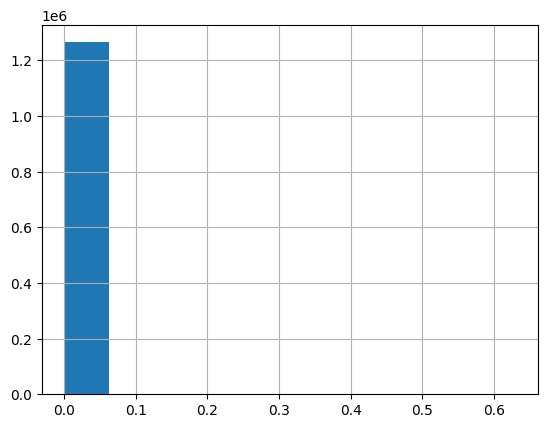

99.0%-quantile: 0.002
99.1%-quantile: 0.002
99.2%-quantile: 0.003
99.3%-quantile: 0.003
99.4%-quantile: 0.003
99.5%-quantile: 0.004
99.6%-quantile: 0.005
99.7%-quantile: 0.006
99.8%-quantile: 0.01
99.9%-quantile: 0.02


In [37]:

# still, we should explore the data more to specify the possible hyperparameters of the algorithm later on

# let us load the preprocessed data

texts_cleaned_loaded = []

with open("cleaned_bfro_descriptions.txt", "r", encoding="utf-8") as f:

    for line in f:

        # split the line back into tokens (words), since they were joined with spaces before

        tokens = line.strip().split()

        texts_cleaned_loaded.append(tokens)



# this function generates n-grams for a list of tokens over a specified range of n values

def generate_ngrams(tokens, ngram_range=(1,3)):



    all_ngrams = []  # this list will store all generated n-grams



    # loop over each n in the range (e.g., 1, 2, 3)

    for n in range(ngram_range[0], ngram_range[1]+1):

        # create sliding windows of length n

        ngrams = zip(*[tokens[i:] for i in range(n)])  # e.g., for bigrams: [tokens[0:], tokens[1:]]

       

        # join tokens with underscores to form n-gram strings

        all_ngrams.extend(['_'.join(gram) for gram in ngrams])

   

    return all_ngrams  # return the complete list of n-grams



# apply n-gram generation to all cleaned texts

# texts_cleaned is a list of documents, each a list of tokens

texts_with_ngrams = [generate_ngrams(doc, ngram_range=(1,3)) for doc in texts_cleaned_loaded]





# this function computes TF, DF, IDF, TF-IDF for all the tokens under consideration



def compute_tfidf(texts):



    N = len(texts)  # number of documents

   

    # 1. Compute TF for each document

    tf_docs = []

    for doc in texts:

        counts = Counter(doc)

        total_words = len(doc)

        tf_doc = {word: count / total_words for word, count in counts.items()}

        tf_docs.append(tf_doc)

   

    # 2. Compute DF for each token (fraction of docs containing the token)

    df_dict = {}

    for doc in texts:

        for token in set(doc):

            df_dict[token] = df_dict.get(token, 0) + 1

    df_dict = {token: count / N for token, count in df_dict.items()}

   

    # 3. Compute IDF

    idf_dict = {token: math.log(1 / df) for token, df in df_dict.items()}

   

    # 4. Compute TF-IDF for each document

    tfidf_docs = []

    for tf_doc in tf_docs:

        tfidf_doc = {token: tf_val * idf_dict[token] for token, tf_val in tf_doc.items()}

        tfidf_docs.append(tfidf_doc)

   

    return tf_docs, df_dict, idf_dict, tfidf_docs



tf_docs, df_dict, idf_dict, tfidf_docs = compute_tfidf(texts_with_ngrams)



# usually we are interested in DF, primarily due to its intuitive interpretation

# initial analysis of DF is the first step towards filtering out the too frequent and too rare tokens



# let us sort DF dictionary in descending order and take top 100

top100_df = dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)[:100])



# here we present top 25 tokens according to DF statistic

for token, df in top100_df.items():

    print(f"{token}: {df:.3f}")





# get all DF values

df_values = list(df_dict.values())



# basic statistics

print("Min. =", np.round(min(df_values), 3))

print("Max. =", np.round(max(df_values), 3))

print("Mean =", np.round(statistics.mean(df_values), 3))

print("Median =", np.round(statistics.median(df_values), 3))

print("Std. dev. =", np.round(statistics.stdev(df_values), 3))



pd.Series(df_values).hist()



plt.show()





for i in range(990,1000,1):

    print(i/10,'%-quantile: ',np.round(np.quantile(df_values, i/1000),3),sep='')

In [38]:
import numpy as np

import nltk

# Assuming other necessary imports (HDBSCAN, BERTopic, etc.) are already done above



# --- STEP 1: Component Preparation (STOPWORDS and HDBSCAN) ---

print(f"Number of texts in 'texts' variable: {len(texts)}")



if len(texts) < 10:

    print("WARNING: You have too little data for parameters min_df=5 and max_df=0.6!")



# 1a. Building the final list of stopwords (from all iterations)

try:

    nltk.data.find('corpora/stopwords')

except LookupError:

    print("Downloading NLTK stopwords...")

    nltk.download('stopwords')

   

stop_words = set(nltk.corpus.stopwords.words('english'))

custom_words_to_add = {

    # Previous:

    'like', 'could', 'would', 'one', 'time', 'us', 'went', 'night',

    'get', 'know', 'see', 'saw', 'back', 'looked', 'got', 'around',

    'something', 'thing', 'things', 'said', 'say', 'go', 'going',

    'way', 'day', 'even', 'never', 'much', 'made', 'man', 'person', 'people',

   

    # --- NEW (SUPER-CLUSTER CULPRITS) ---

    'sound', 'sounds', 'sounded',  # Must go to distinguish sound types (scream vs whistle)

    'came', 'come',

    'started', 'start',

    'camp', 'camping', 'tent',     # Event background, not the topic itself

    'trail', 'road',               # Background

    'hear', 'heard',               # Perception verb

    'friend', 'friends', 'partner', # Characters

    'deep', 'woods', 'forest',     # Location (all are in the forest, so this doesn't differentiate)

    'loud', 'felt', 'away', 'right', 'left', 'area'

}

stop_words = stop_words.union(custom_words_to_add)



# IMPORTANT: CountVectorizer requires a list, not a set

stop_words_list = list(stop_words)

print(f"Initialization with {len(stop_words_list)} total stopwords.")



# 1b. Defining our relaxed HDBSCAN model (CRITICAL!)

hdbscan_model = HDBSCAN(

    min_cluster_size=15,  # You can leave 10 or slightly increase to 15

    min_samples=2,        # <-- THIS IS A KEY CHANGE. Try 5, 3, or 1.

    metric='euclidean',

    cluster_selection_method='eom',

    prediction_data=True

)



umap_model = UMAP.UMAP(

        n_neighbors = 50,        # number of neighbors used to build local manifold structure

        n_components = 5,        # number of dimensions for the reduced embeddings

        metric = 'cosine',       # distance metric used for measuring similarity

        min_dist = 0.0,          # minimum distance between points in the low-dimensional space

        random_state = 42        # random seed for reproducibility

        )



# --- STEP 2: Improved Vectorizer Configuration ---



embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

tokenizer = RegexpTokenizer(r'\w+')



# FIX: Setting filters and stopwords

tfidf_vectorizer = CountVectorizer(

    ngram_range = (1, 2),       # Changed: We capture bigrams (phrases) too

    max_df = 0.7,               # filter by maximum document frequency

    min_df = 2,                 # FIX: Word must appear in at least 2 documents

    tokenizer = tokenizer.tokenize,

    stop_words = stop_words_list # FIX: Using our full list of stopwords

)



ctfidf_model = ClassTfidfTransformer()

representation_model = KeyBERTInspired()



# --- STEP 3: Improved BERTopic Initialization ---

print("Initializing BERTopic with custom HDBSCAN and vectorizer...")

topic_model = BERTopic(

    embedding_model = embedding_model,

    umap_model = umap_model,

    hdbscan_model = hdbscan_model,  # FIX: Uncommented, now active

    vectorizer_model = tfidf_vectorizer, # Passing the improved vectorizer

    ctfidf_model = ctfidf_model,

    top_n_words = 10,

    verbose = True,                

    calculate_probabilities = True,

    representation_model = representation_model

    # Removed 'language="english"', because it's now in the vectorizer

)



# --- STEP 4: Training and Results (unchanged) ---

print("Starting model training...")

# Ensure 'texts' is your list of cleaned (but *before* stopword removal) texts

topics, probabilities = topic_model.fit_transform(texts)



print("\n--- MODEL RESULTS (after all fixes) ---")

print(topic_model.get_topic_info())



print("\n--- 5 most frequent topics (excluding outliers) ---")

print(topic_model.get_topic_info().head(6))





# ==============================================================================

# STEP 4: Intelligent Outlier Reduction

# ==============================================================================



# Set threshold (e.g., 60% confidence)

probability_threshold = 0.60



print(f"\nStarting outlier reduction with threshold: {probability_threshold}")

print(f"Outliers BEFORE: {topics.count(-1)}")



# Create a copy of topics to modify

new_topics = list(topics)



# Check if probabilities exist

if probabilities is not None and len(np.shape(probabilities)) == 2:

    count_recovered = 0

   

    # Iterate through all documents

    for i, topic in enumerate(new_topics):

        # We only care about outliers (-1)

        if topic == -1:

            # Find max probability for this document

            max_prob = max(probabilities[i])

            candidate_topic = np.argmax(probabilities[i])

           

            # If confidence is high enough, reassign

            if max_prob >= probability_threshold:

                new_topics[i] = candidate_topic

                count_recovered += 1



    print(f"Recovered {count_recovered} documents with confidence >= {probability_threshold}")



else:

    print("ERROR: No probability matrix found. Ensure calculate_probabilities=True")



# Update the model with new topics

# Note: We pass the vectorizer again to ensure keywords remain sharp

topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)



print(f"Outliers AFTER: {new_topics.count(-1)}")

print("\n--- TOPICS AFTER REDUCTION ---")

print(topic_model.get_topic_info().head(10))





# ==============================================================================

# STEP 5: English Labeling & Visualization (CORRECTED VERSION)

# ==============================================================================



# 1. Define English Labels

topic_labels = {

    -1: "Outliers / Noise",

    0:  "Roadside Sightings & Highway Crossings",

    1:  "Camping Noises & Rustling",

    2:  "Hiking Encounters & Ravines",

    3:  "Footprints & Track Finding",

    4:  "Residential & Driveway Sightings",

    5:  "General Sightings & Rural Reports",

    6:  "Creek & Waterway Activity",

    7:  "Creature Movement Observations",

    8:  "Yellowstone & River Fishing",

    9:  "Gorilla-like Visual Descriptions",

    10: "Large & Hairy Descriptions",

    11: "Growling, Wolves & Dog Reactions",

    12: "Hunting Encounters (Hillside)",

    13: "General Encounter Stories",

    14: "Wildlife Areas & Hunting Clubs",

    15: "Hunter Backstories",

    16: "Anatomy: Legs & Feet",

    17: "Bipedal Walking vs. Bears",

    18: "Highway Standoffs & Cattle",

    19: "Heavy Bipedal Footsteps",

    20: "Surveillance & Military Bases",

    21: "Bear-like Descriptions",

    22: "Steep Terrain & Treelines",

    23: "Barn & Farm Encounters",

    24: "Trailheads & Creek Beds",

    25: "Backyard Woodline & Barking",

    26: "Vocalizations & Screams (Scenic)",

    27: "Skunk Smell & Animal Chasing",

    28: "Village & Garden Intrusions",

    29: "Climbing & Gullies",

    30: "Roars & Screams",

    31: "High Strangeness & UFO Connections",

    32: "Tree Shaking & Physical Disturbances",

    33: "Flatfooted Tracks & Strolling"

}



# 2. Apply Labels to the model

topic_model.set_topic_labels(topic_labels)



# 3. Generate Charts that DO NOT require UMAP (Safe)



# A. Bar Chart (Keywords)

print("Generating Bar Chart...")

fig_bar = topic_model.visualize_barchart(top_n_topics=15, custom_labels=True)

fig_bar.write_html("final_topics_english.html")

print("Saved: final_topics_english.html")



# B. Hierarchy (Dendrogram)

print("Generating Hierarchy...")

fig_tree = topic_model.visualize_hierarchy(custom_labels=True)

fig_tree.write_html("final_hierarchy.html")

print("Saved: final_hierarchy.html")



# C. Heatmap (Similarity)

print("Generating Heatmap...")

try:

    fig_heat = topic_model.visualize_heatmap(custom_labels=True)

    fig_heat.write_html("heatmap_similarity.html")

    print("Saved: heatmap_similarity.html")

except Exception as e:

    print(f"Skipping heatmap due to error: {e}")



# 4. Generate the 'Galaxy Map' (Document Visualization)

# This bypasses the internal UMAP error by calculating coordinates manually.



print("Generating Document Map (Galaxy View)...")



# A. Calculate embeddings (vectors) for all texts

# (This might take a minute)

embeddings = embedding_model.encode(texts, show_progress_bar=True)



# B. Manually reduce to 2D using UMAP



umap_2d = UMAP.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42)

reduced_embeddings = umap_2d.fit_transform(embeddings)



# C. Visualize Documents (This function accepts 'reduced_embeddings')

# Note: We visualize a sample if the dataset is huge, but 5000 is fine to show all.

fig_docs = topic_model.visualize_documents(

    texts,

    reduced_embeddings=reduced_embeddings,

    custom_labels=True,

    hide_annotations=True # Set to False if you want to see words on the map

)

fig_docs.write_html("final_galaxy_map.html")

print("SUCCESS! Saved: final_galaxy_map.html")



# 5. Save Model

topic_model.save("my_bigfoot_model_final", serialization="safetensors", save_ctfidf=True)

print("Model saved successfully.")

Number of texts in 'texts' variable: 4981
Initialization with 256 total stopwords.


2025-12-09 02:09:35,524 - BERTopic - Embedding - Transforming documents to embeddings.


Initializing BERTopic with custom HDBSCAN and vectorizer...
Starting model training...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

2025-12-09 02:10:51,989 - BERTopic - Embedding - Completed ✓
2025-12-09 02:10:51,992 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-09 02:11:05,230 - BERTopic - Dimensionality - Completed ✓
2025-12-09 02:11:05,234 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-09 02:11:05,825 - BERTopic - Cluster - Completed ✓
2025-12-09 02:11:05,854 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-09 02:11:11,012 - BERTopic - Representation - Completed ✓
2025-12-09 02:11:11,936 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



--- MODEL RESULTS (after all fixes) ---
    Topic  Count                                               Name  \
0      -1   2005                   -1_footsteps_hike_hillside_roads   
1       0    682      0_ditch_tree line_side highway_across highway   
2       1    551         1_wilderness_footsteps_rustling_campground   
3       2    378                     2_wilderness_hike_hiked_ravine   
4       3    151   3_trails_bigfoot tracks_deer tracks_tracks along   
5       4    122            4_front yard_pasture_driveway_neighbors   
6       5    121  5_bigfoot sightings_seen bigfoot_bigfoots_seen...   
7       6     85    6_footsteps_side creek_across creek_sugar creek   
8       7     76  7_creature walking_bigfoot prints_animal cross...   
9       8     66            8_boulder_yellowstone_elk_river fishing   
10      9     65     9_ditch_headed south_observed creature_gorilla   
11     10     54  10_seen huge_creature covered_work sight_mount...   
12     11     54        11_tree line

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

SUCCESS! Saved: final_galaxy_map.html
Model saved successfully.


### 3.1 Text Length Analysis & Sanity Check
Before proceeding to modeling, we examine the distribution of document lengths to verify data quality:

1. **Descriptive Statistics:**
   * Calculate **Min, Max, Mean, Median, and Standard Deviation** of character counts.
   * **Rationale:** This identifies potential outliers. Extremely short texts (noise) or extremely long texts can affect embedding performance. We want to ensure there is enough semantic content in each document.

2. **Distribution Visualization:**
   * Plot a **Histogram** of text lengths.
   * **Rationale:** Visualizing the shape of the data helps us understand if the reports are consistent in length or if there is a skew (e.g., mostly short descriptions with a few long outliers).

3. **Final Duplicate Verification:**
   * **Rationale:** A final boolean check ensures that our previous deduplication logic worked correctly and the corpus contains unique entries only.

Min. = 1
Max. = 30374
Mean = 1910.43
Median = 1414.5
Std. dev. = 1876.56


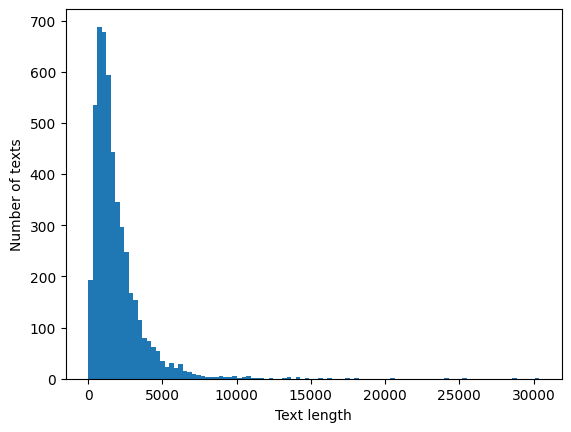

Contains duplicates? False


In [5]:
texts_lengths = [len(text) for text in docs]  # get the length of each text

# basic descriptive statistics of the texts length
print("Min. =", np.round(min(texts_lengths),2))                     # minimum length
print("Max. =", np.round(max(texts_lengths),2))                     # maximum length
print("Mean =", np.round(statistics.mean(texts_lengths),2))         # average length
print("Median =", np.round(statistics.median(texts_lengths),2))     # median length
print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))   # standard deviation

# most importantly: there are no empty documents; the shortest are 3/4 of the A4 page

# plot a histogram of text lengths
plt.hist(texts_lengths, bins=100)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.show()

# we should always check for duplicates; here there is no such an issue
has_duplicates = len(docs) != len(set(docs))
print("Contains duplicates?", has_duplicates)

In [6]:
len(docs)

5017

In [7]:
texts_lengths = [len(text) for text in docs]  # get the length of each text

# basic descriptive statistics of the texts length
print("Min. =", np.round(min(texts_lengths),2))                     # minimum length
print("Max. =", np.round(max(texts_lengths),2))                     # maximum length
print("Mean =", np.round(statistics.mean(texts_lengths),2))         # average length
print("Median =", np.round(statistics.median(texts_lengths),2))     # median length
print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))   # standard deviation

# most importantly: there are no empty documents; the shortest are 3/4 of the A4 page

Min. = 47
Max. = 30990
Mean = 2482.67
Median = 1973
Std. dev. = 2030.2


4. TEXT LENGTH ANALYSIS

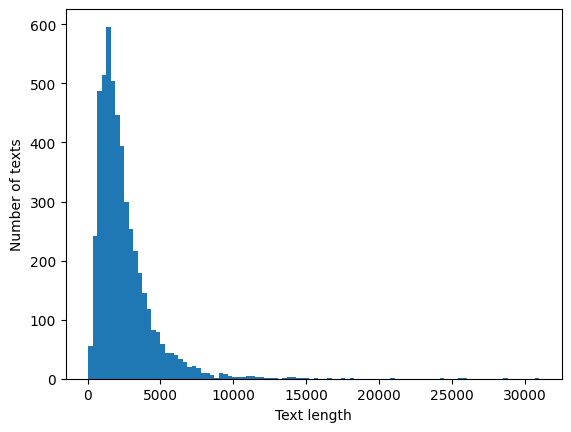

In [8]:
# plot a histogram of text lengths
plt.hist(texts_lengths, bins=100)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.show()

5. CHECK FOR DUPLICATES

In [9]:
# we should always check for duplicates; here there is no such an issue
has_duplicates = len(docs) != len(set(docs))
print("Contains duplicates?", has_duplicates)

Contains duplicates? False


## 4. Advanced Text Preprocessing
Based on the insights from the EDA (Section 3), we apply a rigorous cleaning pipeline to reduce noise and standardize the dataset. This step is critical for improving the quality of topic clusters by removing non-semantic elements.

### 4.1 Cleaning Logic
We define a custom cleaning function to handle specific noise patterns found in the text:

1. **Stopwords Removal:**
   * We utilize the `nltk` English stopwords list to remove high-frequency, low-meaning words (e.g., "the", "is", "at") identified in the Frequency Analysis.
   
2. **Noise Reduction (Regex):**
   * **Artifacts:** Removal of URLs, user mentions (`@user`), and "rt" tokens.
   * **Formatting:** Removal of punctuation, numbers, and single isolated letters.
   * **Normalization:** Conversion to lowercase and whitespace trimming.

3. **Data Persistence:**
   * The cleaned corpus is saved to `cleaned_bfro_descriptions.txt` to allow for reproducibility.

In [10]:
# --- Stopwords Configuration ---

# Download stopwords list (only needed the first time)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')

# Load stopwords list
stop_words = set(nltk.corpus.stopwords.words('english'))
print(f"Stopwords list updated. Total count: {len(stop_words)}")

# --- Text Cleaning Function ---
def clean_text(text, stop_words_set):
    """
    Cleans a text string by removing URLs, mentions, 'rt' tokens, 
    punctuation, numbers, single letters, stopwords, and excess whitespace.
    """
    text = str(text).lower()  # Convert to lowercase and ensure string format
    
    # Remove URLs (http or https)
    text = re.sub(r'https?://\S+', '', text)
    
    # Remove user mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Convert hashtags to plain text (e.g., #datascience -> datascience)
    text = re.sub(r'#(\w+)', r'\1', text) 
    
    # Remove the "rt" (retweet) token
    text = re.sub(r'\brt\b', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove standalone single letters
    text = re.sub(r'\b[a-zA-Z]\b', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove Stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words_set]
    return ' '.join(cleaned_words)

# --- Cleaning Execution ---
print("Cleaning texts for BERTopic (including stopwords)...")

# We use the 'docs' list created in previous steps (which combines Observed + Environment)
# instead of reloading just the 'OBSERVED' column.
texts = [clean_text(doc, stop_words) for doc in docs]

# Remove any empty strings that might have resulted from heavy cleaning
texts = [text for text in texts if text]

print(f"Cleaning complete. Remaining documents: {len(texts)}")

# --- Result Verification ---
print("\n--- Example of cleaning ---")
if len(docs) > 0 and len(texts) > 0:
    # Print the first real item from dataset
    print(f"ORIGINAL (fragment):\n{docs[0][:150]}...\n")
    print(f"CLEANED (fragment):\n{texts[0][:150]}...")
    
# Saving cleaned texts for further processing
output_filename = 'cleaned_bfro_descriptions.txt'
with open(output_filename, 'w', encoding='utf-8') as f:
    for text in texts:
        f.write(text + '\n')

print(f"\nSuccessfully saved cleaned data to '{output_filename}'")

Stopwords list updated. Total count: 198
Cleaning texts for BERTopic (including stopwords)...
Cleaning complete. Remaining documents: 4981

--- Example of cleaning ---
ORIGINAL (fragment):
i was canoeing on the sipsey river in alabama. it was dusk as i was pulling out of the river and i was trying to hurry to get all my gear in the car b...

CLEANED (fragment):
canoeing sipsey river alabama dusk pulling river trying hurry get gear car got dark yard walk steep hill car flipping canoe put shoulders heard loud w...

Successfully saved cleaned data to 'cleaned_bfro_descriptions.txt'


In [11]:
# still, we should explore the data more to specify the possible hyperparameters of the algorithm later on
# let us load the preprocessed data
texts_cleaned_loaded = []
with open("cleaned_bbc_descriptions.txt", "r", encoding="utf-8") as f:
    for line in f:
        # split the line back into tokens (words), since they were joined with spaces before
        tokens = line.strip().split()
        texts_cleaned_loaded.append(tokens)

In [12]:
# this function generates n-grams for a list of tokens over a specified range of n values
def generate_ngrams(tokens, ngram_range=(1,3)):

    all_ngrams = []  # this list will store all generated n-grams

    # loop over each n in the range (e.g., 1, 2, 3)
    for n in range(ngram_range[0], ngram_range[1]+1):
        # create sliding windows of length n
        ngrams = zip(*[tokens[i:] for i in range(n)])  # e.g., for bigrams: [tokens[0:], tokens[1:]]
        
        # join tokens with underscores to form n-gram strings
        all_ngrams.extend(['_'.join(gram) for gram in ngrams])
    
    return all_ngrams  # return the complete list of n-grams

# apply n-gram generation to all cleaned texts
# texts_cleaned is a list of documents, each a list of tokens
texts_with_ngrams = [generate_ngrams(doc, ngram_range=(1,3)) for doc in texts_cleaned_loaded]

In [17]:
# this function computes TF, DF, IDF, TF-IDF for all the tokens under consideration

def compute_tfidf(texts):

    N = len(texts)  # number of documents
    
    # 1. Compute TF for each document
    tf_docs = []
    for doc in texts:
        counts = Counter(doc)
        total_words = len(doc)
        tf_doc = {word: count / total_words for word, count in counts.items()}
        tf_docs.append(tf_doc)
    
    # 2. Compute DF for each token (fraction of docs containing the token)
    df_dict = {}
    for doc in texts:
        for token in set(doc):
            df_dict[token] = df_dict.get(token, 0) + 1
    df_dict = {token: count / N for token, count in df_dict.items()}
    
    # 3. Compute IDF
    idf_dict = {token: math.log(1 / df) for token, df in df_dict.items()}
    
    # 4. Compute TF-IDF for each document
    tfidf_docs = []
    for tf_doc in tf_docs:
        tfidf_doc = {token: tf_val * idf_dict[token] for token, tf_val in tf_doc.items()}
        tfidf_docs.append(tfidf_doc)
    
    return tf_docs, df_dict, idf_dict, tfidf_docs

tf_docs, df_dict, idf_dict, tfidf_docs = compute_tfidf(texts_with_ngrams)

# usually we are interested in DF, primarily due to its intuitive interpretation
# initial analysis of DF is the first step towards filtering out the too frequent and too rare tokens

# let us sort DF dictionary in descending order and take top 100
top100_df = dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)[:100])

# here we present top 25 tokens according to DF statistic
for token, df in top100_df.items():
    print(f"{token}: {df:.3f}")

like: 0.630
back: 0.610
saw: 0.562
could: 0.527
heard: 0.524
around: 0.520
see: 0.506
one: 0.501
time: 0.491
area: 0.474
something: 0.470
looked: 0.441
went: 0.432
feet: 0.423
would: 0.422
got: 0.415
road: 0.415
away: 0.393
us: 0.385
never: 0.383
two: 0.380
woods: 0.380
large: 0.377
thought: 0.374
side: 0.366
tall: 0.361
night: 0.355
didnt: 0.343
get: 0.337
came: 0.336
seen: 0.334
way: 0.329
right: 0.326
first: 0.323
long: 0.323
left: 0.321
know: 0.315
day: 0.315
dark: 0.313
said: 0.313
anything: 0.304
walking: 0.302
bigfoot: 0.302
go: 0.300
looking: 0.299
turned: 0.293
thing: 0.291
look: 0.291
started: 0.290
told: 0.289
made: 0.284
years: 0.284
hair: 0.281
next: 0.280
sound: 0.276
still: 0.273
took: 0.268
creature: 0.265
ran: 0.264
across: 0.263
walked: 0.263
yards: 0.261
big: 0.260
going: 0.257
behind: 0.255
tree: 0.252
head: 0.250
stopped: 0.247
also: 0.242
bear: 0.241
animal: 0.237
later: 0.235
foot: 0.231
trees: 0.231
hear: 0.230
home: 0.228
deer: 0.225
minutes: 0.221
found: 0.220

Min. = 0.0
Max. = 0.63
Mean = 0.0
Median = 0.0
Std. dev. = 0.004


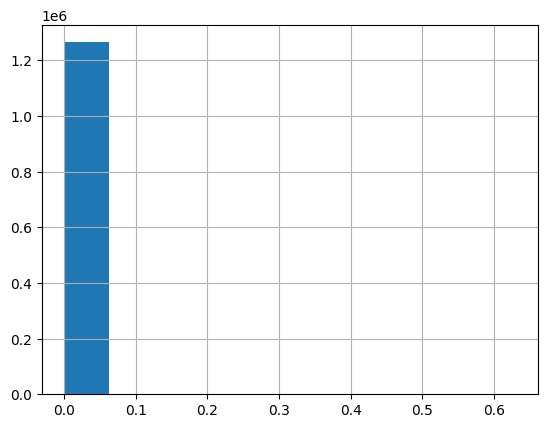

In [20]:
# get all DF values
df_values = list(df_dict.values())

# basic statistics
print("Min. =", np.round(min(df_values), 3))
print("Max. =", np.round(max(df_values), 3))
print("Mean =", np.round(statistics.mean(df_values), 3))
print("Median =", np.round(statistics.median(df_values), 3))
print("Std. dev. =", np.round(statistics.stdev(df_values), 3))

pd.Series(df_values).hist()

plt.show()

In [21]:
for i in range(990,1000,1):
    print(i/10,'%-quantile: ',np.round(np.quantile(df_values, i/1000),3),sep='')

99.0%-quantile: 0.002
99.1%-quantile: 0.002
99.2%-quantile: 0.003
99.3%-quantile: 0.003
99.4%-quantile: 0.003
99.5%-quantile: 0.004
99.6%-quantile: 0.005
99.7%-quantile: 0.006
99.8%-quantile: 0.01
99.9%-quantile: 0.02


In [ ]:
# 1. Define STOPWORDS (Defined locally to avoid NameError)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    
stop_words = set(nltk.corpus.stopwords.words('english'))

# Custom domain-specific stopwords
custom_words_to_add = {
    'like', 'could', 'would', 'one', 'time', 'us', 'went', 'night', 
    'get', 'know', 'see', 'saw', 'back', 'looked', 'got', 'around', 
    'something', 'thing', 'things', 'said', 'say', 'go', 'going',
    'way', 'day', 'even', 'never', 'much', 'made', 'man', 'person', 'people',
    'sound', 'sounds', 'sounded', 'came', 'come', 'started', 'start', 
    'camp', 'camping', 'tent', 'trail', 'road', 'hear', 'heard',               
    'friend', 'friends', 'partner', 'deep', 'woods', 'forest',     
    'loud', 'felt', 'away', 'right', 'left', 'area'
}
stop_words = stop_words.union(custom_words_to_add)
stop_words_list = list(stop_words) # <--- CRITICAL DEFINITION

print(f"Stopwords ready. Count: {len(stop_words_list)}")

# 2. Define SUB-MODELS
umap_model = UMAP.UMAP(
    n_neighbors=15, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15, 
    min_samples=2,       
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

# 3. Configure VECTORIZER (Uses stop_words_list defined above)
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),        
    max_df=0.7,               
    min_df=2,                 
    tokenizer=tokenizer.tokenize,
    stop_words=stop_words_list 
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()

# 4. INITIALIZE & TRAIN BERTOPIC
print("Initializing BERTopic...")
topic_model = BERTopic(
    embedding_model=embedding_model, 
    umap_model=umap_model, 
    hdbscan_model=hdbscan_model, 
    vectorizer_model=vectorizer_model, 
    ctfidf_model=ctfidf_model, 
    representation_model=representation_model,
    top_n_words=10,
    verbose=True,                 
    calculate_probabilities=True  
)

print("Starting model training (Fit & Transform)... this might take a minute.")
# Ensure we use 'texts' (the cleaned list from Section 4)
topics, probabilities = topic_model.fit_transform(texts)

print("\n--- Initial Training Complete ---")
print(topic_model.get_topic_info().head(6))

Stopwords ready. Count: 256


2025-12-09 01:58:01,790 - BERTopic - Embedding - Transforming documents to embeddings.


Initializing BERTopic...
Starting model training (Fit & Transform)... this might take a minute.


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

2025-12-09 01:59:16,492 - BERTopic - Embedding - Completed ✓
2025-12-09 01:59:16,494 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-09 01:59:23,832 - BERTopic - Dimensionality - Completed ✓
2025-12-09 01:59:23,834 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-09 01:59:24,604 - BERTopic - Cluster - Completed ✓
2025-12-09 01:59:24,608 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-09 01:59:30,794 - BERTopic - Representation - Completed ✓



--- Initial Training Complete ---
   Topic  Count                                         Name  \
0     -1   2068           -1_sightings_yard_rocks_campground   
1      0    299            0_ravine_tree line_hunters_hunted   
2      1    208         1_sightings_front yard_pasture_grass   
3      2    151    2_wildlife_yard_coyotes_dogs neighborhood   
4      3    136  3_trails_bigfoot tracks_tracks along_hiking   
5      4    134         4_footsteps_meadow_canyon_state park   

                                      Representation  \
0  [sightings, yard, rocks, campground, fishing, ...   
1  [ravine, tree line, hunters, hunted, hearing, ...   
2  [sightings, front yard, pasture, grass, bushes...   
3  [wildlife, yard, coyotes, dogs neighborhood, n...   
4  [trails, bigfoot tracks, tracks along, hiking,...   
5  [footsteps, meadow, canyon, state park, mounta...   

                                 Representative_Docs  
0  [september adult son daughter son hiked twin s...  
1  [unsuccess

In [26]:
# ==============================================================================
# STEP 2: Vectorizer & Embeddings Configuration
# ==============================================================================

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

# Pre-calculate embeddings once to speed up optimization 10x
print("Pre-calculating embeddings for optimization...")
embeddings = embedding_model.encode(texts, show_progress_bar=True)

tfidf_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_df=0.7,
    min_df=2,
    tokenizer=tokenizer.tokenize,
    stop_words=stop_words_list
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()

# ==============================================================================
# STEP 2.5: AUTOMATED PARAMETER OPTIMIZATION (Grid Search)
# ==============================================================================

def compute_coherence_score(topic_model, docs):
    """Calculates the C_v coherence score for a trained BERTopic model."""
    # Preprocess documents
    cleaned_docs = topic_model._preprocess_text(docs)
    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    
    # Extract topic words
    topic_words = []
    topics = topic_model.get_topic_info()
    for topic in topics[topics['Topic'] != -1]['Topic']:
        words = [word for word, _ in topic_model.get_topic(topic)]
        topic_words.append(words)
        
    # Calculate Coherence
    if not topic_words:
        return 0
        
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    coherence_model = CoherenceModel(topics=topic_words, 
                                     texts=tokens, 
                                     dictionary=dictionary, 
                                     coherence='c_v')
    return coherence_model.get_coherence()

# --- Define the Grid to Search ---
# Adjust these lists to test different values
param_grid = {
    'min_cluster_size': [10, 15, 25],       # HDBSCAN: How big a topic must be
    'n_neighbors': [15, 30, 50]             # UMAP: Global vs Local structure
}

best_score = -1
best_params = {}

print("\n--- STARTING HYPERPARAMETER OPTIMIZATION ---")
print(f"Testing combinations: {len(param_grid['min_cluster_size']) * len(param_grid['n_neighbors'])}")

# Loop through parameters
for cluster_size in param_grid['min_cluster_size']:
    for neighbors in param_grid['n_neighbors']:
        
        # 1. Configure Sub-models
        hdbscan_opt = HDBSCAN(min_cluster_size=cluster_size, min_samples=2, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
        umap_opt = UMAP.UMAP(n_neighbors=neighbors, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
        
        # 2. Initialize & Train BERTopic
        # Note: We pass pre-calculated 'embeddings' to fit_transform to make it fast
        model = BERTopic(embedding_model=embedding_model, umap_model=umap_opt, hdbscan_model=hdbscan_opt, vectorizer_model=tfidf_vectorizer, verbose=False)
        model.fit_transform(texts, embeddings)
        
        # 3. Calculate Score
        score = compute_coherence_score(model, texts)
        
        print(f"Params [Cluster: {cluster_size}, Neighbors: {neighbors}] -> Coherence: {score:.4f}")
        
        # 4. Update Best
        if score > best_score:
            best_score = score
            best_params = {'min_cluster_size': cluster_size, 'n_neighbors': neighbors}

print(f"\n>>> OPTIMIZATION COMPLETE. Best Score: {best_score:.4f}")
print(f">>> Best Parameters: {best_params}")


# ==============================================================================
# STEP 3: Train Final Model with BEST Parameters
# ==============================================================================

print("\nInitializing Final BERTopic with Optimized Parameters...")

# Re-initialize sub-models with winning parameters
final_hdbscan = HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=2, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

final_umap = UMAP.UMAP(
    n_neighbors=best_params['n_neighbors'],
    n_components=5, 
    metric='cosine', 
    min_dist=0.0, 
    random_state=42
)

topic_model = BERTopic(
    embedding_model=embedding_model, 
    umap_model=final_umap, 
    hdbscan_model=final_hdbscan,
    vectorizer_model=tfidf_vectorizer,
    ctfidf_model=ctfidf_model, 
    representation_model=representation_model,
    top_n_words=10,
    verbose=True,                 
    calculate_probabilities=True
)

# --- STEP 4: Training and Results ---
print("Training Final Model...")
topics, probabilities = topic_model.fit_transform(texts, embeddings)

print("\n--- FINAL MODEL RESULTS ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 4: Intelligent Outlier Reduction
# ==============================================================================

# Set threshold (e.g., 60% confidence)
probability_threshold = 0.60

print(f"\nStarting outlier reduction with threshold: {probability_threshold}")
print(f"Outliers BEFORE: {topics.count(-1)}")

# Create a copy of topics to modify
new_topics = list(topics)

# Check if probabilities exist
if probabilities is not None and len(np.shape(probabilities)) == 2:
    count_recovered = 0
    
    # Iterate through all documents
    for i, topic in enumerate(new_topics):
        # We only care about outliers (-1)
        if topic == -1:
            # Find max probability for this document
            max_prob = max(probabilities[i])
            candidate_topic = np.argmax(probabilities[i])
            
            # If confidence is high enough, reassign
            if max_prob >= probability_threshold:
                new_topics[i] = candidate_topic
                count_recovered += 1

    print(f"Recovered {count_recovered} documents with confidence >= {probability_threshold}")

else:
    print("ERROR: No probability matrix found. Ensure calculate_probabilities=True")

# Update the model with new topics
topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)

print(f"Outliers AFTER: {new_topics.count(-1)}")
print("\n--- TOPICS AFTER REDUCTION ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 5: English Labeling & Visualization
# ==============================================================================

# Note: Since parameters changed, topics might change IDs. 
# We use an automated labeling approach based on keywords instead of hardcoded dictionary here
# or you can re-map them manually after seeing the result.

# Auto-generating English labels from top keywords for the final chart
topic_labels = topic_model.generate_topic_labels(nr_words=3, topic_prefix=False, separator=" | ")
topic_model.set_topic_labels(topic_labels)

print("Generating Document Map (Galaxy View)...")

# Reuse the pre-calculated embeddings for visualization
umap_2d = UMAP.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_2d.fit_transform(embeddings)

fig_docs = topic_model.visualize_documents(
    texts, 
    reduced_embeddings=reduced_embeddings, 
    custom_labels=True,
    hide_annotations=True
)
fig_docs.write_html("final_galaxy_map_optimized.html")
print("SUCCESS! Saved: final_galaxy_map_optimized.html")

# Save Model
topic_model.save("my_bigfoot_model_optimized", serialization="safetensors", save_ctfidf=True)
print("Optimized Model saved successfully.")

Pre-calculating embeddings for optimization...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

NameError: name 'stop_words_list' is not defined

In [28]:
# --- STEP 1: Component Preparation ---
print(f"Number of texts processing: {len(texts)}")

# 1a. Stopwords
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')
    
stop_words = set(nltk.corpus.stopwords.words('english'))
custom_words_to_add = {
    'like', 'could', 'would', 'one', 'time', 'us', 'went', 'night', 
    'get', 'know', 'see', 'saw', 'back', 'looked', 'got', 'around', 
    'something', 'thing', 'things', 'said', 'say', 'go', 'going',
    'way', 'day', 'even', 'never', 'much', 'made', 'man', 'person', 'people',
    'sound', 'sounds', 'sounded', 
    'came', 'come', 'started', 'start', 
    'camp', 'camping', 'tent', 
    'trail', 'road', 
    'hear', 'heard', 
    'friend', 'friends', 'partner', 
    'deep', 'woods', 'forest', 
    'loud', 'felt', 'away', 'right', 'left', 'area'
}
stop_words = stop_words.union(custom_words_to_add)
stop_words_list = list(stop_words)

# 1b. HDBSCAN (Relaxed)
hdbscan_model = HDBSCAN(
    min_cluster_size=15, 
    min_samples=2, 
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# 1c. UMAP (Broad View - User Preference)
umap_model = UMAP.UMAP(
        n_neighbors = 50,  
        n_components = 5, 
        metric = 'cosine', 
        min_dist = 0.0, 
        random_state = 42
)

# --- STEP 2: Vectorizer ---
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

tfidf_vectorizer = CountVectorizer(
    ngram_range = (1, 2), 
    max_df = 0.7, 
    min_df = 2, 
    tokenizer = tokenizer.tokenize,
    stop_words = stop_words_list
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()

# --- STEP 3: Initialization ---
print("Initializing BERTopic...")
topic_model = BERTopic(
    embedding_model = embedding_model, 
    umap_model = umap_model, 
    hdbscan_model = hdbscan_model, 
    vectorizer_model = tfidf_vectorizer, 
    ctfidf_model = ctfidf_model, 
    top_n_words = 10,
    verbose = True, 
    calculate_probabilities = True,
    representation_model = representation_model
)

# --- STEP 4: Training ---
print("Starting model training...")
# Check if embeddings are already calculated to save time
if 'embeddings' not in locals():
    print("Calculating embeddings...")
    embeddings = embedding_model.encode(texts, show_progress_bar=True)

topics, probabilities = topic_model.fit_transform(texts, embeddings)

print("\n--- MODEL RESULTS ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 4: Outlier Reduction (Probability Based)
# ==============================================================================

probability_threshold = 0.60
print(f"\nStarting outlier reduction (Threshold: {probability_threshold})...")
print(f"Outliers BEFORE: {topics.count(-1)}")

new_topics = list(topics)

if probabilities is not None:
    count_recovered = 0
    for i, topic in enumerate(new_topics):
        if topic == -1:
            max_prob = max(probabilities[i])
            candidate_topic = np.argmax(probabilities[i])
            if max_prob >= probability_threshold:
                new_topics[i] = candidate_topic
                count_recovered += 1

    print(f"Recovered {count_recovered} documents.")
else:
    print("No probabilities found.")

# Update model
topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)
print(f"Outliers AFTER: {new_topics.count(-1)}")

# ==============================================================================
# STEP 5: Visualization & Export
# ==============================================================================

# WARNING: Topic IDs change every run! 
# Only uncomment the lines below AFTER checking the table above to ensure ID mapping is correct.

topic_labels = {
    -1: "Outliers / Noise",
    0:  "Roadside Sightings & Highway Crossings",
    1:  "Camping Noises & Rustling",
    2:  "Hiking Encounters & Ravines",
    3:  "Footprints & Track Finding",
    4:  "Residential & Driveway Sightings",
    # ... add/adjust your labels based on the new results ...
}

# topic_model.set_topic_labels(

Number of texts processing: 5017


2025-12-09 01:49:49,144 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Initializing BERTopic...
Starting model training...


2025-12-09 01:50:01,874 - BERTopic - Dimensionality - Completed ✓
2025-12-09 01:50:01,876 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-09 01:50:02,516 - BERTopic - Cluster - Completed ✓
2025-12-09 01:50:02,521 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-09 01:50:08,728 - BERTopic - Representation - Completed ✓
2025-12-09 01:50:09,897 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



--- MODEL RESULTS ---
   Topic  Count                                               Name  \
0     -1   2555                     -1_creeks_hiked_footsteps_hike   
1      0    247          0_ditch_side highway_hilly_across highway   
2      1    220             1_front yard_pasture_backyard_driveway   
3      2    184           2_wooded areas_creeks_neighbors_backyard   
4      3    125                3_hike_wilderness_campground_camped   
5      4    103               4_meadows_wilderness_firewood_meadow   
6      5    102           5_ravines_footsteps_ravine_crossed creek   
7      6     92  6_bigfoot sightings_bigfoot sighting_seen bigf...   
8      7     91                 7_pasture_treeline_grassy_roadside   
9      8     88       8_boulder_boulders_rocky river_river fishing   

                                      Representation  \
0  [creeks, hiked, footsteps, hike, wilderness, l...   
1  [ditch, side highway, hilly, across highway, r...   
2  [front yard, pasture, backyard, dri